In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('diabetes.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


# checking whether there is any duplicate value or not

In [3]:
data.duplicated().sum()

np.int64(3854)

## Removing duplicate value

In [4]:
data = data.drop_duplicates()

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               96146 non-null  object 
 1   age                  96146 non-null  float64
 2   hypertension         96146 non-null  int64  
 3   heart_disease        96146 non-null  int64  
 4   smoking_history      96146 non-null  object 
 5   bmi                  96146 non-null  float64
 6   HbA1c_level          96146 non-null  float64
 7   blood_glucose_level  96146 non-null  int64  
 8   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 7.3+ MB


In [7]:
data.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


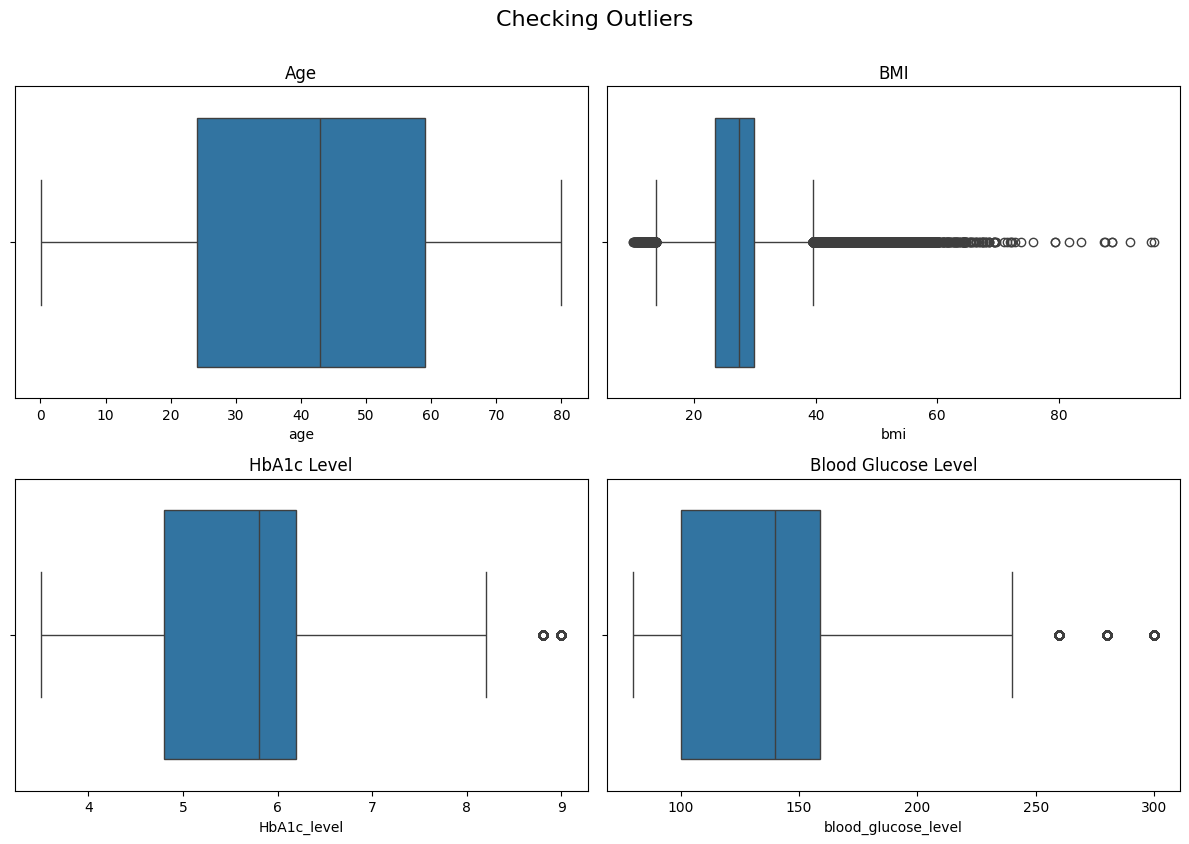

In [9]:
plt.figure(figsize=(12, 8))

# Age
plt.subplot(2, 2, 1)
sns.boxplot(x=data['age'])
plt.title("Age")

# BMI
plt.subplot(2, 2, 2)
sns.boxplot(x=data['bmi'])
plt.title("BMI")

# HbA1c_level
plt.subplot(2, 2, 3)
sns.boxplot(x=data['HbA1c_level'])
plt.title("HbA1c Level")

# Blood Glucose
plt.subplot(2, 2, 4)
sns.boxplot(x=data['blood_glucose_level'])
plt.title("Blood Glucose Level")

# Adjust layout and show once
plt.tight_layout()
plt.suptitle("Checking Outliers", fontsize=16, y=1.05)  # Title for the whole figure
plt.show()


## Outlier Handling for bmi

In [10]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)

cap_outliers_iqr(data, 'bmi')


C:\Users\DELL\AppData\Local\Temp\ipykernel_19224\801906840.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(lower, upper)


In [11]:
data.shape

(96146, 9)

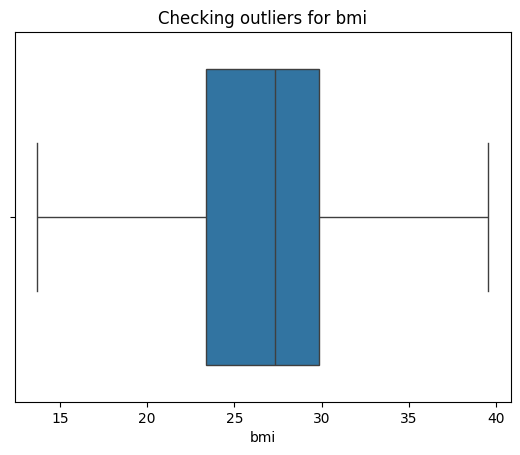

In [12]:
sns.boxplot(x=data['bmi'])
plt.title("Checking outliers for bmi")
plt.show()

## Outlier handling for blood_glucose_level and HbA1c_level

In [13]:
def count_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers.shape[0]  # returns the count


outlier_count_bgl = count_outliers_iqr(data, 'blood_glucose_level')
outlier_count_hba = count_outliers_iqr(data, 'HbA1c_level')
print(f"Number of outliers in 'blood_glucose_level': {outlier_count_bgl}")
print(f"Number of outliers in 'HbA1c_level': {outlier_count_hba}")


Number of outliers in 'blood_glucose_level': 2031
Number of outliers in 'HbA1c_level': 1312


In [14]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower, upper)

cap_outliers_iqr(data, 'blood_glucose_level')
cap_outliers_iqr(data, 'HbA1c_level')


C:\Users\DELL\AppData\Local\Temp\ipykernel_19224\1586717397.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(lower, upper)
C:\Users\DELL\AppData\Local\Temp\ipykernel_19224\1586717397.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].clip(lower, upper)


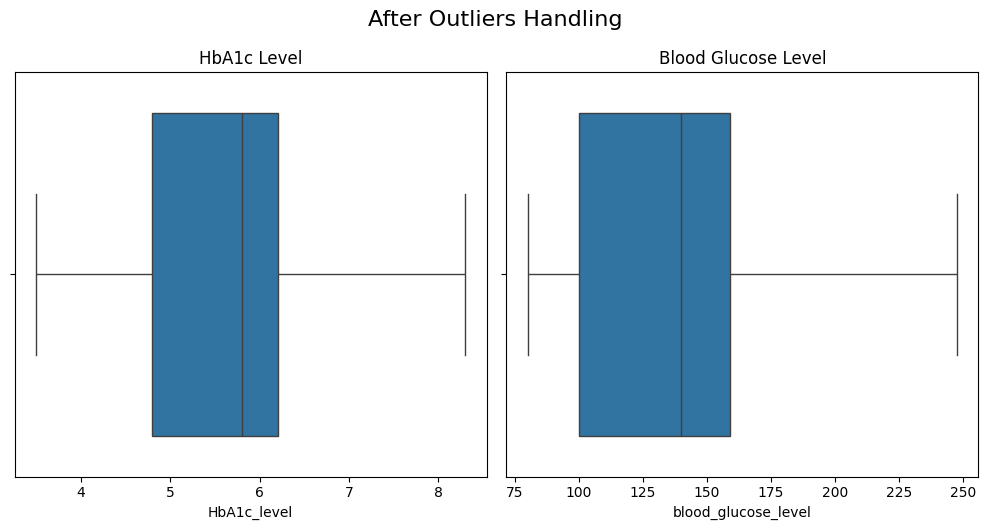

In [15]:
plt.figure(figsize=(10, 5))

# HbA1c_level
plt.subplot(1, 2, 1)
sns.boxplot(x=data['HbA1c_level'])
plt.title("HbA1c Level")

# Blood Glucose
plt.subplot(1, 2, 2)
sns.boxplot(x=data['blood_glucose_level'])
plt.title("Blood Glucose Level")

# Adjust layout and show once
plt.tight_layout()
plt.suptitle("After Outliers Handling", fontsize=16, y=1.05)  # Title for the whole figure
plt.show()


## Mapping gender column

In [16]:
data['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [17]:
data['gender'] = data['gender'].map({'Female': 0, 'Male': 1,'Other':2})

C:\Users\DELL\AppData\Local\Temp\ipykernel_19224\285849148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['gender'] = data['gender'].map({'Female': 0, 'Male': 1,'Other':2})


## using one hot encoding to smoking_history

In [18]:
data['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [19]:
from sklearn.preprocessing import OneHotEncoder

# Create the encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for dense array

# Fit and transform the smoking_history column
encoded_data = ohe.fit_transform(data[['smoking_history']])

# Create a DataFrame with appropriate column names
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(['smoking_history']))

# Align index before concatenating
encoded_df.index = data.index

# Drop the original column and add new one-hot encoded columns
data = pd.concat([data.drop('smoking_history', axis=1), encoded_df], axis=1)


In [20]:
data

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0,80.0,0,1,25.19,6.6,140.0,0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,54.0,0,0,27.32,6.6,80.0,0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,28.0,0,0,27.32,5.7,158.0,0,0.0,0.0,0.0,0.0,1.0,0.0
3,0,36.0,0,0,23.45,5.0,155.0,0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,76.0,1,1,20.14,4.8,155.0,0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,24.60,4.8,145.0,0,1.0,0.0,0.0,0.0,0.0,0.0
99996,0,2.0,0,0,17.37,6.5,100.0,0,1.0,0.0,0.0,0.0,0.0,0.0
99997,1,66.0,0,0,27.83,5.7,155.0,0,0.0,0.0,0.0,1.0,0.0,0.0
99998,0,24.0,0,0,35.42,4.0,100.0,0,0.0,0.0,0.0,0.0,1.0,0.0


In [21]:
data.describe()

,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.00000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,0.416065,41.794326,0.077601,0.040803,27.030939,5.52443,137.523584,0.088220,0.342053,0.095657,0.041583,0.096717,0.357768,0.066222
std,0.493287,22.462948,0.267544,0.197833,5.920013,1.04950,38.639660,0.283616,0.474400,0.294121,0.199634,0.295574,0.479346,0.248671
min,0.000000,0.080000,0.000000,0.000000,13.710000,3.50000,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.000000,0.000000,0.000000,23.400000,4.80000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,43.000000,0.000000,0.000000,27.320000,5.80000,140.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,59.000000,0.000000,0.000000,29.860000,6.20000,159.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2.000000,80.000000,1.000000,1.000000,39.550000,8.30000,247.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


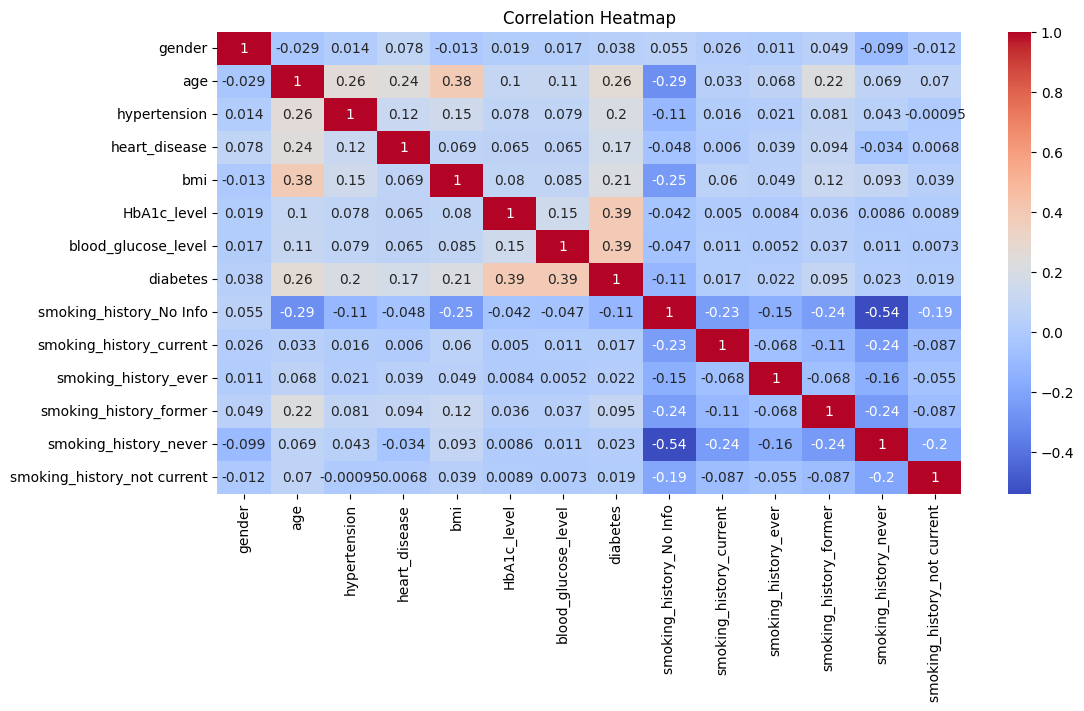

In [22]:
# Heatmap
corr = data.corr()
plt.figure(figsize=(12,6))
sns.heatmap(corr,cmap="coolwarm",annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Seperating input and output columns

In [23]:
x = data.drop('diabetes',axis=1)
y = data['diabetes']

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

## Model fitting

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

# Automatically scales X_train and fits the model
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
model.fit(X_train, y_train)



,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Assuming y_test is true label and y_pred is predicted class
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Print all metrics
print(f"Accuracy Score     : {accuracy:.4f}")
print(f"Precision Score    : {precision:.4f}")
print(f"Recall Score       : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC AUC Score      : {roc_auc:.4f}")

Accuracy Score     : 0.9559
Precision Score    : 0.8467
Recall Score       : 0.6194
F1 Score           : 0.7154
ROC AUC Score      : 0.9615


In [28]:
import pickle

In [29]:
with open('model.pkl','wb') as f:
    pickle.dump(model,f)